[0] Loss: 0.6618, Acc: 0.6875
[10] Loss: 0.6520, Acc: 0.6875
[20] Loss: 0.6505, Acc: 0.6250
[30] Loss: 0.5502, Acc: 0.8750
[40] Loss: 0.5495, Acc: 0.9375
[50] Loss: 0.6251, Acc: 0.6875
[60] Loss: 0.5040, Acc: 0.8750
[70] Loss: 0.5409, Acc: 0.8750
[80] Loss: 0.4887, Acc: 0.9375
[90] Loss: 0.5561, Acc: 0.7500
[100] Loss: 0.4300, Acc: 0.9375
[110] Loss: 0.4338, Acc: 1.0000
[120] Loss: 0.5047, Acc: 0.9375
[130] Loss: 0.4748, Acc: 0.9375
[140] Loss: 0.4341, Acc: 0.9375
[150] Loss: 0.5143, Acc: 0.8125
[160] Loss: 0.5521, Acc: 0.8125
[170] Loss: 0.4038, Acc: 0.9375
[180] Loss: 0.4416, Acc: 0.8750
[190] Loss: 0.4954, Acc: 0.8750
[200] Loss: 0.4557, Acc: 0.9375
[210] Loss: 0.5930, Acc: 0.6875
[220] Loss: 0.5591, Acc: 0.7500
[230] Loss: 0.4923, Acc: 0.8125
[240] Loss: 0.5091, Acc: 0.7500
[250] Loss: 0.5386, Acc: 0.7500
[260] Loss: 0.5578, Acc: 0.6250
[270] Loss: 0.4332, Acc: 0.8750
[280] Loss: 0.4153, Acc: 0.9375
[290] Loss: 0.4617, Acc: 0.8750
[300] Loss: 0.5368, Acc: 0.7500
[310] Loss: 0.4494,

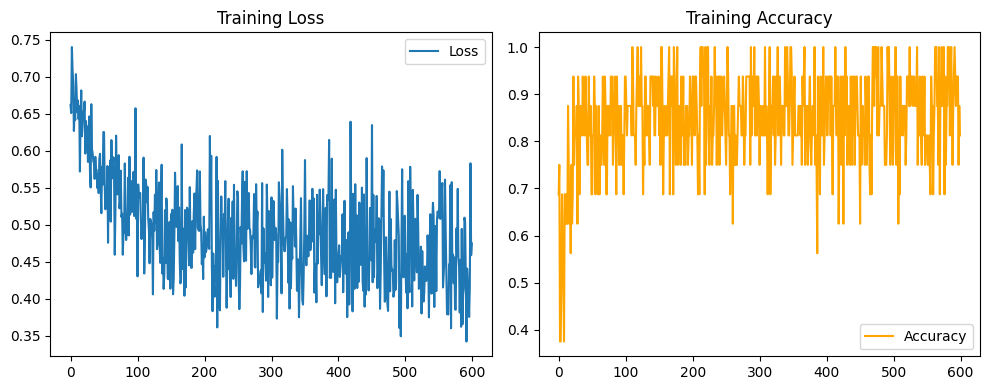

In [5]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_scheduler
from model import SentimentClassifier
from dataset import MyDataset, collate_fn
from utils import save_model, plot_curves

def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SentimentClassifier().to(device)

    train_dataset = MyDataset('train')
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                              collate_fn=collate_fn, drop_last=True)

    optimizer = AdamW(model.parameters(), lr=5e-4)
    scheduler = get_scheduler('linear', optimizer=optimizer,
                              num_warmup_steps=0,
                              num_training_steps=len(train_loader))
    criterion = torch.nn.CrossEntropyLoss()

    model.train()
    losses, accs = [], []

    for step, (input_ids, attention_mask, token_type_ids, labels) in enumerate(train_loader):
        input_ids, attention_mask, token_type_ids, labels = \
            input_ids.to(device), attention_mask.to(device), token_type_ids.to(device), labels.to(device)

        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        acc = (outputs.argmax(dim=1) == labels).float().mean().item()
        losses.append(loss.item())
        accs.append(acc)

        if step % 10 == 0:
            print(f"[{step}] Loss: {loss.item():.4f}, Acc: {acc:.4f}")

    save_model(model)
    plot_curves(losses, accs)

if __name__ == '__main__':
    train()


In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import get_scheduler
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm  # 进度条
from utils import save_model

import matplotlib.pyplot as plt
from matplotlib import rcParams

from model import SentimentClassifier
from dataset import MyDataset, collate_fn
from visualize_metrics import *
from datasets import load_from_disk

# 设置中文字体，避免出现乱码问题
rcParams['font.family'] = 'SimHei'  # 使用黑体
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

def ensure_dir(directory):
    """确保目录存在，如果不存在则创建"""
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Directory '{directory}' created.")
    else:
        print(f"Directory '{directory}' already exists.")

def evaluate(model, loader, device):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()

    all_loss, all_acc, all_f1, all_prec, all_recall = [], [], [], [], []
    y_true_all, y_pred_all, y_prob_all = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", ncols=100):
            input_ids, att_mask, token_ids, labels = [b.to(device) for b in batch]

            logits = model(input_ids, att_mask, token_ids)
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)[:, 1].cpu()
            preds = logits.argmax(dim=1).cpu()
            labels = labels.cpu()

            all_loss.append(loss.item())
            all_acc.append((preds == labels).float().mean().item())
            all_f1.append(f1_score(labels, preds, zero_division=0))
            all_prec.append(precision_score(labels, preds, zero_division=0))
            all_recall.append(recall_score(labels, preds, zero_division=0))

            y_true_all.extend(labels.tolist())
            y_pred_all.extend(preds.tolist())
            y_prob_all.extend(probs.tolist())

    return {
        "loss": sum(all_loss) / len(all_loss),
        "acc": sum(all_acc) / len(all_acc),
        "f1": sum(all_f1) / len(all_f1),
        "precision": sum(all_prec) / len(all_prec),
        "recall": sum(all_recall) / len(all_recall),
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "y_probs": y_prob_all
    }


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, scaler):
    model.train()
    total_loss, total_acc, total_preds, total_labels = [], [], [], []

    for batch in tqdm(loader, desc="Training", ncols=100):
        input_ids, att_mask, token_ids, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        with autocast():  # Mixed Precision Training
            logits = model(input_ids, att_mask, token_ids)
            loss = criterion(logits, labels)

        # 混合精度训练的反向传播
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()

        total_loss.append(loss.item())
        total_acc.append(acc)
        total_preds.extend(preds.cpu().tolist())
        total_labels.extend(labels.cpu().tolist())

    return {
        "loss": sum(total_loss) / len(total_loss),
        "acc": sum(total_acc) / len(total_acc),
        "f1": f1_score(total_labels, total_preds, zero_division=0),
    }


def train(epochs=10, batch_size=32, val_batch_size=64, patience=3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SentimentClassifier().to(device)

    train_loader = DataLoader(MyDataset('train'), batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True)
    val_loader = DataLoader(MyDataset('test'), batch_size=val_batch_size, shuffle=False, collate_fn=collate_fn)

    optimizer = AdamW(model.parameters(), lr=5e-5)  # 调整学习率
    scheduler = get_scheduler('linear', optimizer=optimizer, num_warmup_steps=0, num_training_steps=epochs * len(train_loader))
    criterion = torch.nn.CrossEntropyLoss()

    # 混合精度训练
    scaler = GradScaler()

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    best_val_f1 = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        print(f"\n📘 Epoch {epoch}/{epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device, scaler)
        val_metrics = evaluate(model, val_loader, device)

        for key in train_metrics:
            history[f"train_{key}"].append(train_metrics[key])
        for key in ['loss', 'acc', 'f1']:
            history[f"val_{key}"].append(val_metrics[key])

        print(f"Train → Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f}")
        print(f" Val  → Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f}")

        # EarlyStopping: 如果验证集F1未改善，提前停止训练
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            epochs_without_improvement = 0
            save_model(model,'models/sentiment_model_best.pth')  # 保存模型
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("🏁 Early stopping triggered. Model is saved.")
                break

    ensure_dir('images')

    # 保存所有的图表
    plot_curve(history["train_loss"], "训练损失", "images/train_loss.png")
    plot_curve(history["val_loss"], "验证损失", "images/val_loss.png")
    plot_curve(history["train_acc"], "训练准确率", "images/train_acc.png")
    plot_curve(history["val_acc"], "验证准确率", "images/val_acc.png")
    plot_curve(history["train_f1"], "训练F1得分", "images/train_f1.png")
    plot_curve(history["val_f1"], "验证F1得分", "images/val_f1.png")
    plot_pr_curve(val_metrics['y_true'], val_metrics['y_probs'], "images/pr_curve.png")
    plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "images/confusion_matrix.png")
    plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "images/confusion_matrix_normalized.png", normalize=True)

    print("🎉 训练完成，图表已保存在 images/ 目录！")


if __name__ == '__main__':
    dataset = load_from_disk('./dataset/ChnSentiCorp')
    print(dataset)
    print("✅ Keys:", dataset.keys())
    train()


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 0
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1200
    })
})
✅ Keys: dict_keys(['train', 'validation', 'test'])


/tmp/ipykernel_2145/2293552221.py:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



📘 Epoch 1/10


Training:   0%|                                                             | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_2145/2293552221.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed Precision Training
Evaluating: 100%|███████████████████████████████████████████████████| 19/19 [00:12<00:00,  1.52it/s]


Train → Loss: 0.6357 | Acc: 0.7059 | F1: 0.7306
 Val  → Loss: 0.5731 | Acc: 0.8459 | F1: 0.8454

📘 Epoch 2/10


...

Train → Loss: 0.4586 | Acc: 0.8704 | F1: 0.8689
 Val  → Loss: 0.4476 | Acc: 0.8832 | F1: 0.8843

📘 Epoch 10/10


Training:   0%|                                                             | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_2145/2293552221.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed Precision Training
Evaluating: 100%|███████████████████████████████████████████████████| 19/19 [00:12<00:00,  1.52it/s]
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/root/bert-base-chinese/bert-base-chinese/visualize_metrics.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.savefi

Train → Loss: 0.4543 | Acc: 0.8721 | F1: 0.8710
 Val  → Loss: 0.4450 | Acc: 0.8832 | F1: 0.8843
Directory 'images' already exists.


findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not

🎉 训练完成，图表已保存在 images/ 目录！
